In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"C:\Users\navee\Desktop\python libraries\Projects series\csv data sets\Titanic_train.csv")
df = data.copy()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
#Dataset me total kitne passengers hain?
df['PassengerId'].count()

np.int64(891)

In [4]:
#Dataset me kitne columns aur rows hain?
print(f'Rows = {df.shape[0]} \nColumns = {df.shape[1]}')

Rows = 891 
Columns = 12


In [5]:
#Har column ka data type check karo.
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
# har column me kitni missing values hain?
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Duplicate rows check karo.
df.duplicated().sum()

np.int64(0)

In [8]:
# Survived column me unique values kya hain?
df['Survived'].unique()

array([0, 1])

In [9]:
# Sex column me unique values aur unki frequencies nikalo.
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [10]:
freq  = df['Sex'].value_counts()
freq

Sex
male      577
female    314
Name: count, dtype: int64

Text(0.5, 1.0, 'Frequency Of Sex in Dataset')

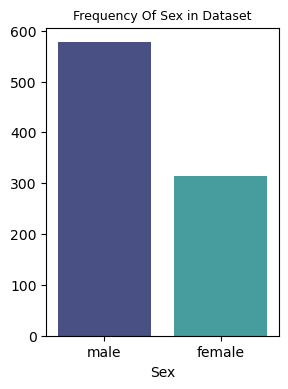

In [11]:
plt.figure(figsize=(3,4))
sns.barplot(x = freq.index , y = freq.values, palette='mako')
plt.title('Frequency Of Sex in Dataset', fontsize = 9)

In [12]:
# Age column me kitni missing values hain?
print(f'Age column contain {df['Age'].isnull().sum()} missing values')

Age column contain 177 missing values


In [13]:
# Cabin column me missing values ka percentage nikalo.
cab = df['Cabin'].isnull().sum()
percent = (cab*100)/df.shape[0]
print(f'In dataset Cabin column contain {percent.round(2)}% missing values ')

In dataset Cabin column contain 77.1% missing values 


In [14]:
# Embarked column me missing values fill karo.
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# check the most frequent value in Emarked column 
df['Embarked'].mode()[0]

'S'

In [16]:
# fill the missing value with 's' which most frequent by using mode 
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [17]:
# verify
df['Embarked'].isnull().sum()

np.int64(0)

- 4. Age ki missing values median se fill karo. 

In [18]:
df['Age'] = df['Age'].fillna(df['Age'].median())
# check again missing value 
df['Age'].isnull().sum()

np.int64(0)

- Cabin column ko drop karne ka decision justify karo.

In [19]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [20]:
# df['Cabin'].isnull().sum() = 687
# df['PassengerId'].count() = 891
miss_val = 687
total_passenger = 891
persent = (miss_val/total_passenger)*100
print(f'Cabin column contain {persent}% missing data ')

Cabin column contain 77.10437710437711% missing data 


In [21]:
# Justification : The Cabin column was dropped because approximately 77% of its values were missing (687 out of 891 records). 
# Such a high proportion of missing data reduces the reliability of imputation and provides limited analytical value.

In [22]:
df.drop(columns='Cabin', inplace=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


- 6.  Kisi bhi categorical column me null values mode se fill karo. 

In [23]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [24]:
# these is no any column with missing or Null values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

_____________

## Univariate Analysis

- Survived ka countplot banao. 


In [25]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


<Axes: xlabel='Survived', ylabel='count'>

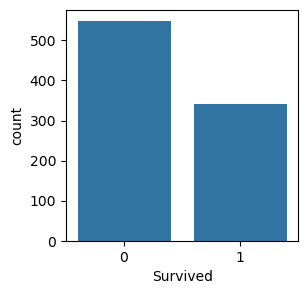

In [26]:
plt.figure(figsize=(3,3))
sns.countplot( data = df, x = 'Survived')

<Axes: xlabel='Survived_label', ylabel='count'>

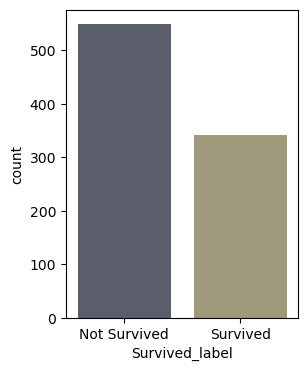

In [27]:
plt.figure(figsize=(3,4))
df['Survived_label'] = df['Survived'].map({ 0: 'Not Survived', 1: 'Survived'})
sns.countplot(data = df, x = 'Survived_label', palette='cividis')

- 2.   Sex ka countplot banao. 

Text(0.5, 1.0, 'Gender Distribution')

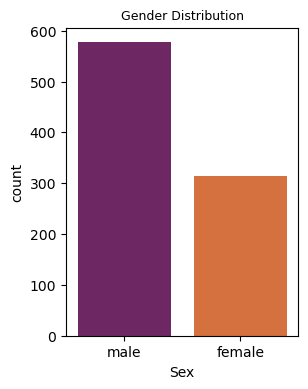

In [28]:
plt.figure(figsize=(3,4))
sns.countplot(data = df , x = 'Sex', palette='inferno')
plt.title('Gender Distribution', fontsize = 9)

- Pclass ka countplot banao.

In [29]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Text(0.5, 1.0, 'Pclass Distribution')

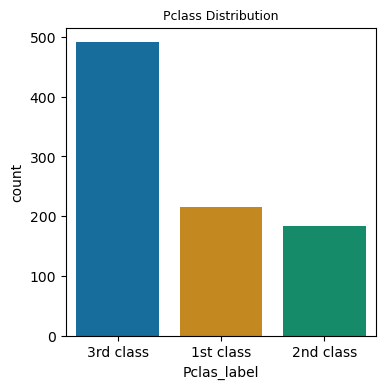

In [30]:
df['Pclas_label'] = df['Pclass'].map({
    1: '1st class',
    2: '2nd class',
    3: '3rd class'
})
plt.figure(figsize=(4,4))
sns.countplot(data = df, x = 'Pclas_label', palette= 'colorblind')
plt.title('Pclass Distribution', fontsize = 9)

- Age ka histogram banao

Text(0.5, 1.0, 'Age DIstribution')

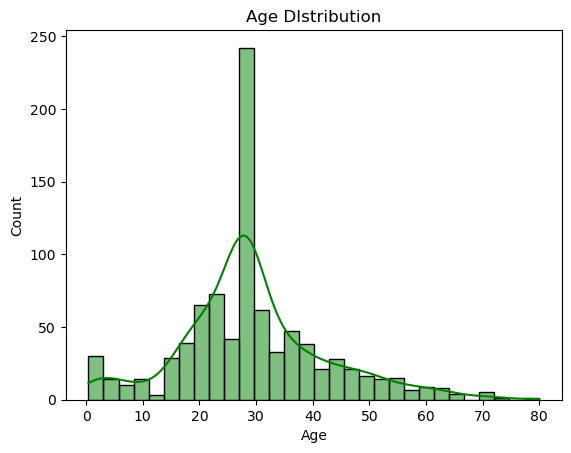

In [31]:
sns.histplot(data = df, x = 'Age', color='g', linewidth = 1, kde = True )
plt.title('Age DIstribution')

- Fare ka histogram banao.

Text(0.5, 0, 'Fare (Price Range)')

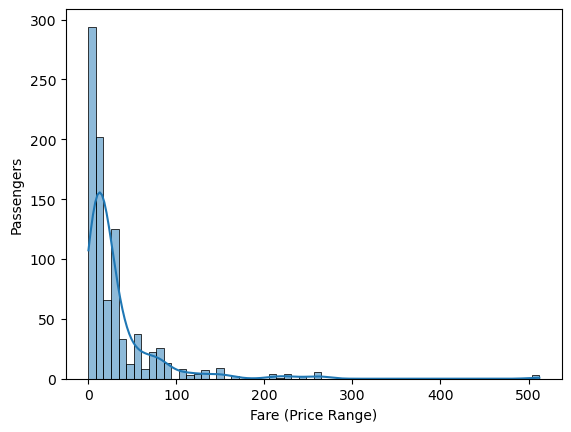

In [32]:
sns.histplot(data = df, x = 'Fare', kde = True)
plt.ylabel('Passengers')
plt.xlabel('Fare (Price Range)')

- 🔍 Observation (important insight)

Zyada passengers ka fare 0 se 50 ke beech hai
Kuch passengers ne 100–200 ka fare diya
Aur ek extreme value 500+ tak ja rahi hai (outlier)

⚠️ Important Concept: Skewed Data: Tumhara histogram right-skewed (positively skewed) hai:
   Left side pe zyada data cluster hai. Right side pe long tail hai (high fares)

___________
- Fare ka boxplot banao

<Axes: xlabel='Fare'>

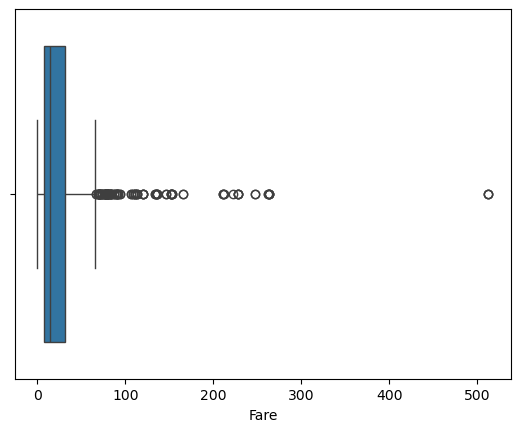

In [33]:
sns.boxplot(data = df, x = 'Fare')

- Age ka boxplot banao. 

<Axes: xlabel='Age'>

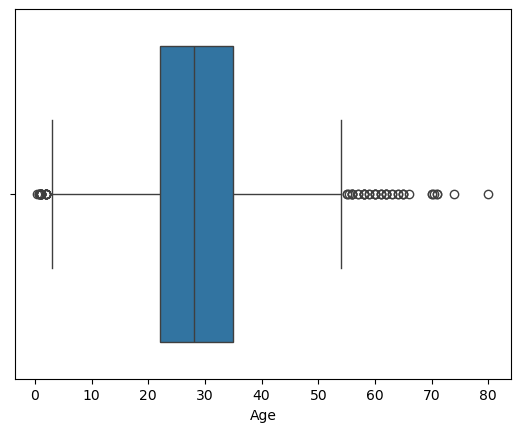

In [34]:
sns.boxplot(x = 'Age', data = df)


- Embarked ka countplot banao.

<Axes: xlabel='Embarked', ylabel='count'>

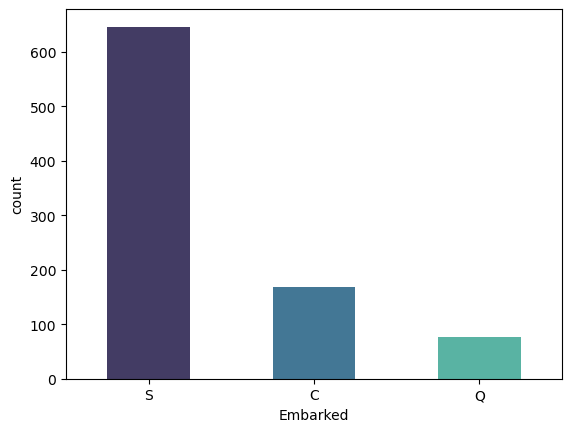

In [35]:
sns.countplot( x = df['Embarked'], palette='mako', width = 0.5)

# Bivariate Analysis

- 1. Gender-wise survival countplot banao. 

In [36]:
df.groupby('Sex')['Survived'].sum()

Sex
female    233
male      109
Name: Survived, dtype: int64

Text(0, 0.5, 'Survival Number')

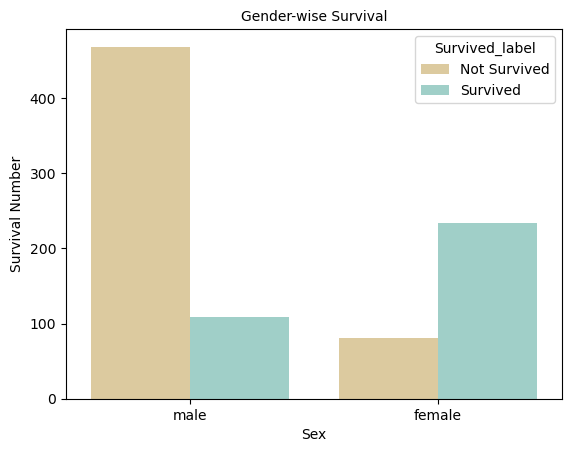

In [37]:
sns.countplot(data = df,
              x= 'Sex',
              hue = 'Survived_label',            
              palette= 'BrBG',
              linewidth = 1
)
plt.title('Gender-wise Survival', fontsize = 10)
plt.ylabel('Survival Number')

_______________
- Pclass-wise survival countplot banao

In [38]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived_label,Pclas_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Not Survived,3rd class
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Survived,1st class
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Survived,3rd class


In [39]:
# Survival rate for P-class
df.groupby('Pclas_label')['Survived'].sum()

Pclas_label
1st class    136
2nd class     87
3rd class    119
Name: Survived, dtype: int64

In [40]:
# nor survival rate for P-class
# Method 1 = Survived == 0 count karo
df[df['Survived'] == 0].groupby('Pclas_label')['Survived'].count()

Pclas_label
1st class     80
2nd class     97
3rd class    372
Name: Survived, dtype: int64

In [41]:
# method 2 = Total - Survived
total = df.groupby('Pclas_label')['Survived'].count()
survived = df.groupby('Pclas_label')['Survived'].sum()
nott = total-survived
nott

Pclas_label
1st class     80
2nd class     97
3rd class    372
Name: Survived, dtype: int64

In [42]:
# method  = (Best for analysis)
pd.crosstab(df['Pclas_label'], df['Survived'], margins=True)

Survived,0,1,All
Pclas_label,,,
1st class,80,136,216
2nd class,97,87,184
3rd class,372,119,491
All,549,342,891


Text(0, 0.5, 'Survival Number')

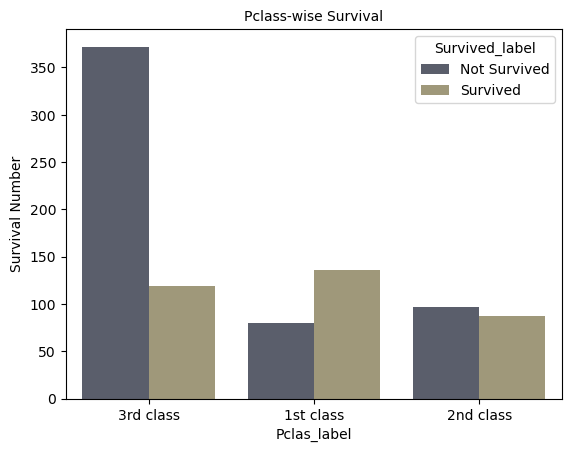

In [43]:
# count plot for Pclass-wise survival
sns.countplot(data = df,
             x = 'Pclas_label',
             hue = 'Survived_label',
             palette='cividis')
plt.title('Pclass-wise Survival', fontsize = 10)
plt.ylabel('Survival Number')

________________
- Embarked-wise survival countplot banao

In [44]:
pd.crosstab(df['Embarked'], df['Survived'], margins=True)

Survived,0,1,All
Embarked,,,
C,75,93,168
Q,47,30,77
S,427,219,646
All,549,342,891


Text(0, 0.5, 'Survival Number')

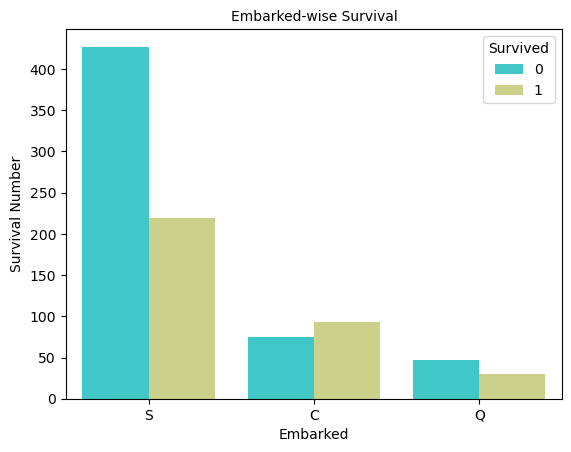

In [45]:
sns.countplot(
    data = df,
    x = 'Embarked',
    hue = 'Survived',
    palette='rainbow'
)
plt.title('Embarked-wise Survival', fontsize = 10)
plt.ylabel('Survival Number')

_____________
- Sex vs Survived ka percentage analysis karo.

In [46]:
sex_survival = pd.crosstab(df['Sex'], df['Survived'], normalize='index')*100
sex_survival.round(2)

Survived,0,1
Sex,,
female,25.80,74.20
male,81.11,18.89


<Axes: xlabel='Sex', ylabel='count'>

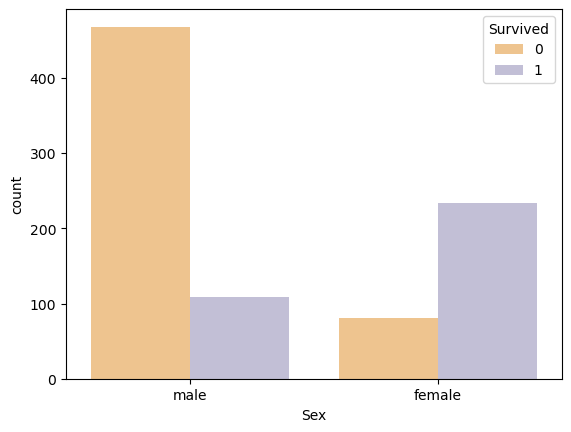

In [47]:
sns.countplot(
    data = df,
    x = 'Sex',
    hue = 'Survived',
    palette='PuOr'
)

____________
- Average Age of survived vs non-survived passengers.

In [48]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived_label,Pclas_label
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,S,Not Survived,3rd class


In [49]:
df.groupby('Survived_label')['Age'].mean()

Survived_label
Not Survived    30.028233
Survived        28.291433
Name: Age, dtype: float64

Text(0.5, 1.0, 'Avg age of survived vs non survived')

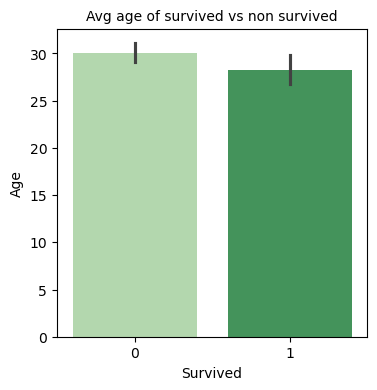

In [50]:
plt.figure(figsize=(4,4))
sns.barplot(
    data = df,
    x = 'Survived',
    y = 'Age',
    palette='Greens'
)
plt.title('Avg age of survived vs non survived', fontsize = 10)

______________
- 6.Average Fare of survived vs non-survived passengers. 

In [51]:
avg_fare = df.groupby('Survived_label')['Fare'].mean()
avg_fare.round(2)

Survived_label
Not Survived    22.12
Survived        48.40
Name: Fare, dtype: float64

Text(0.5, 1.0, 'Avg Fare of Survival vs non Survival')

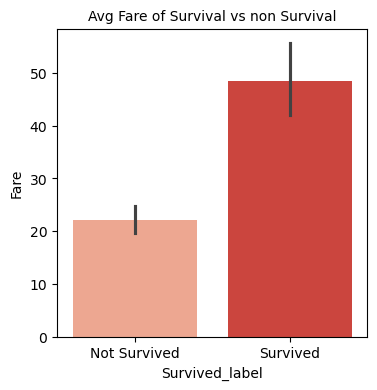

In [52]:
plt.figure(figsize=(4,4))
sns.barplot(
    data = df,
    x = 'Survived_label',
    y = 'Fare',
    palette='Reds'
)
plt.title('Avg Fare of Survival vs non Survival', fontsize = 10)

____________
- Pclass vs Fare boxplot banao. means(Har Passenger Class (1st, 2nd, 3rd) me Fare ki distribution compare karo.)

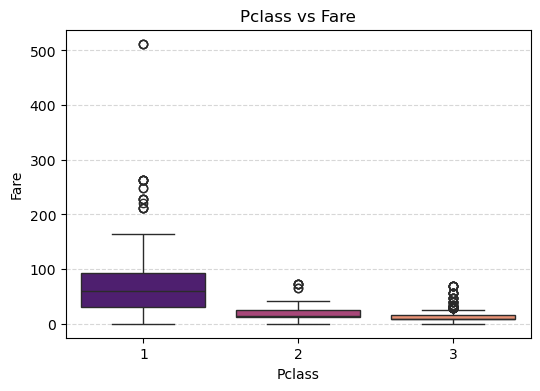

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data = df,
    x = 'Pclass',
    y = 'Fare',
    palette='magma'
    
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Pclass vs Fare')
plt.show()

____________
- ge vs Survived boxplot banao

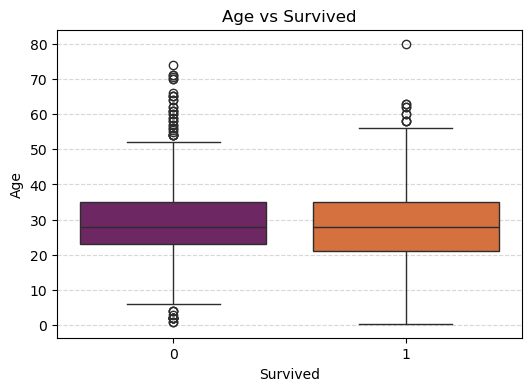

In [54]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data = df,
    x = 'Survived',
    y = 'Age',
    palette='inferno'
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title('Age vs Survived')
plt.show()

_________________
- Fare vs Survived boxplot banao

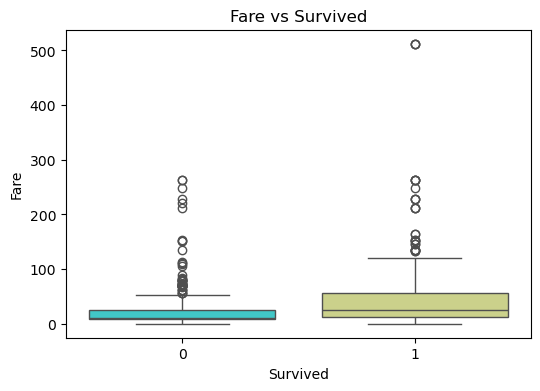

In [55]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data = df,
    x = 'Survived',
    y = 'Fare',
    palette='rainbow'
)
plt.title('Fare vs Survived')
plt.show()

____________
## GroupBy Questions

- Gender-wise average age nikalo

In [57]:
av_age = df.groupby('Sex')['Age'].mean()
av_age.round(2)

Sex
female    27.93
male      30.14
Name: Age, dtype: float64

- Pclass-wise average fare nikalo. 

In [58]:
av_fare = df.groupby('Pclas_label')['Fare'].mean()
av_fare.round(2)

Pclas_label
1st class    84.15
2nd class    20.66
3rd class    13.68
Name: Fare, dtype: float64

- Pclass-wise survival rate nikalo using groupby(). 

In [59]:
df.groupby('Pclas_label')['Survived'].mean() *100

Pclas_label
1st class    62.962963
2nd class    47.282609
3rd class    24.236253
Name: Survived, dtype: float64

- Pclass wise survival count nikalo 

In [60]:
df[df['Survived'] == 1].groupby('Pclas_label')['Survived'].count()

Pclas_label
1st class    136
2nd class     87
3rd class    119
Name: Survived, dtype: int64

- Embarked-wise average fare nikalo

In [61]:
eem = df.groupby('Embarked')['Fare'].mean()
eem.round(2)

Embarked
C    59.95
Q    13.28
S    27.24
Name: Fare, dtype: float64

- Sex-wise average fare nikalo

In [62]:
seex = df.groupby('Sex')['Fare'].mean()
seex.round(2)

Sex
female    44.48
male      25.52
Name: Fare, dtype: float64

- Pclass-wise average age nikalo.

In [63]:
df.groupby('Pclas_label')['Age'].mean()

Pclas_label
1st class    36.812130
2nd class    29.765380
3rd class    25.932627
Name: Age, dtype: float64

- Pclass-wise survival rate nikalo using crosstab().

In [64]:
sur_rate = pd.crosstab(df['Pclas_label'], df['Survived_label'], normalize='index')*100
sur_rate.round(2)

Survived_label,Not Survived,Survived
Pclas_label,,
1st class,37.04,62.96
2nd class,52.72,47.28
3rd class,75.76,24.24


- 7.Survived passengers ki average age nikalo. 

In [65]:
sur = df[df['Survived'] == 1]['Age'].mean()
sur.round(2)

np.float64(28.29)

- Non-survived passengers ki average fare nikalo. 

In [66]:
non_sur = df[df['Survived'] == 0]['Fare'].mean()
non_sur.round(2)

np.float64(22.12)

_______________________
## Advanced EDA Questions

- Sabse zyada passengers kis Pclass me the?

In [68]:
max_pas = df['Pclas_label'].value_counts()
max_pas

Pclas_label
3rd class    491
1st class    216
2nd class    184
Name: count, dtype: int64

<Axes: xlabel='Pclas_label'>

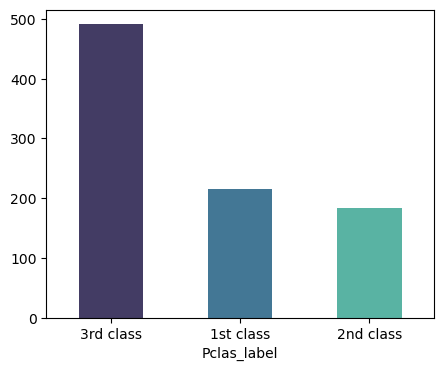

In [69]:
plt.figure(figsize=(5,4))
sns.barplot(x = max_pas.index, y = max_pas.values, palette='mako', width = 0.5)


- Survival rate kis gender ka zyada tha?

In [70]:
(df.groupby('Sex')['Survived'].mean()*100).round(2)

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

- 3.Kis embarkation port se sabse zyada passengers aaye?  

In [71]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [72]:
df['Embarked'].value_counts().idxmax()

'S'

- Sabse mehnga ticket kitne fare ka tha?

In [73]:
df['Fare'].max()

512.3292

In [74]:
# if you want to entire recrord to ye puri row show hogi esy
df[df['Fare'] == df['Fare'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived_label,Pclas_label
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,Survived,1st class
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,Survived,1st class
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,Survived,1st class


- Sabse zyada age wala passenger kitni age ka tha?

In [75]:
df['Age'].max()

80.0

- Sabse zyada age waly kitny passengers thy 

In [76]:
(df['Age'] == df['Age'].max()).sum()

np.int64(1)

- Sabse kam fare kisne pay kiya? 

In [77]:
df[df['Fare'] == df['Fare'].min()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived_label,Pclas_label
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,S,Not Survived,3rd class
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,S,Not Survived,1st class
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,S,Survived,3rd class
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,28.0,0,0,239853,0.0,S,Not Survived,2nd class
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,S,Not Survived,3rd class
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,28.0,0,0,239853,0.0,S,Not Survived,2nd class
466,467,0,2,"Campbell, Mr. William",male,28.0,0,0,239853,0.0,S,Not Survived,2nd class
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.0,0,0,239854,0.0,S,Not Survived,2nd class
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,S,Not Survived,3rd class
633,634,0,1,"Parr, Mr. William Henry Marsh",male,28.0,0,0,112052,0.0,S,Not Survived,1st class


- Kya first class passengers ki survival rate zyada thi?

In [78]:
(df.groupby('Pclas_label')['Survived'].mean()*100).round(2)

Pclas_label
1st class    62.96
2nd class    47.28
3rd class    24.24
Name: Survived, dtype: float64

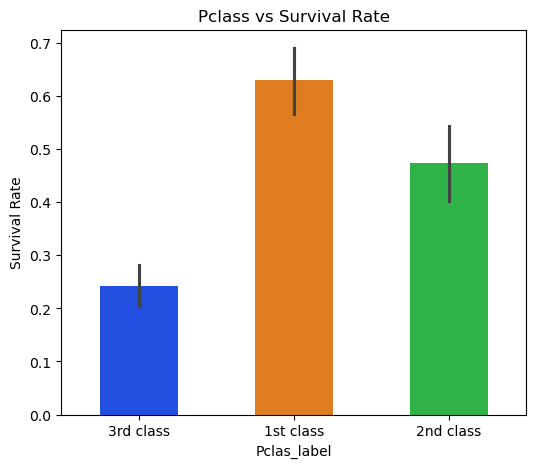

In [79]:
plt.figure(figsize=(6,5))
sns.barplot(
    data=df,
    x='Pclas_label',
    y='Survived',
    palette='bright',
    width = 0.5
)

plt.ylabel('Survival Rate')
plt.title('Pclass vs Survival Rate')
plt.show()

- Kya females ki survival probability males se zyada thi?

In [80]:
(df.groupby('Sex')['Survived'].mean()*100).round(2)

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

- Kya high fare dene walon ki survival rate zyada thi?

In [81]:
#➡️ Fare ko 2 groups me divide kar raha hai:
# Median se zyada Fare → High Fare
# Median se kam ya barabar Fare → Low Fare

df['Fare_group'] = df['Fare'].apply(
     lambda x: 'High fare' if x> df['Fare'].median()
     else 'Low Fare'
)
(df.groupby('Fare_group')['Survived'].mean()*100).round(2)

Fare_group
High fare    51.80
Low Fare     25.06
Name: Survived, dtype: float64

- Kya young passengers zyada survive hue? 

In [82]:
# b sy pehly hm age ko 2 groups me divide krygy 
# median sy ziyada age -> old
# median sy kam age -> young

df['Age_Group'] = df['Age'].apply(
    lambda x: 'Young' if x < df['Age'].median()
    else 'Old'
)
(df.groupby('Age_Group')['Survived'].mean()*100).round(2)

Age_Group
Old      36.28
Young    41.84
Name: Survived, dtype: float64

_______________________
## Visualization Practice

- Age distribution with KDE plot banao. 

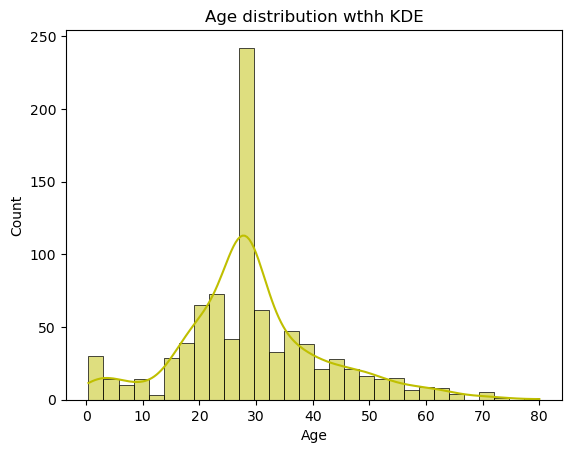

In [96]:
sns.histplot(data = df, x = 'Age',color='y' ,kde = True, linewidth = 0.5)
plt.title('Age distribution wthh KDE')
plt.show()

- Age ka sirf KDE plot banao

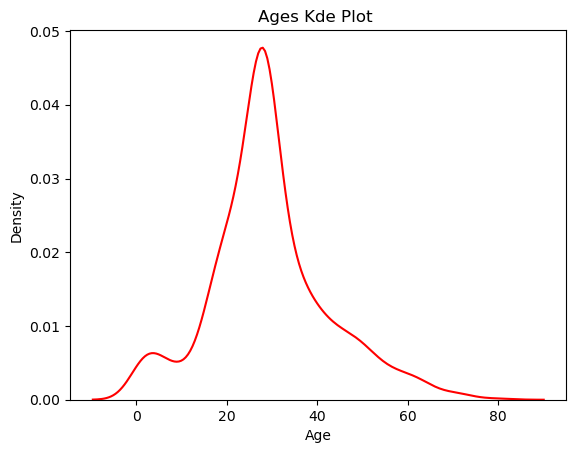

In [92]:
sns.kdeplot(data = df, x = 'Age', color='red')
plt.title('Ages Kde Plot ')
plt.show()

- Fare distribution with KDE plot banao.

Text(0.5, 1.0, 'Fare Distribution with Kde Plot')

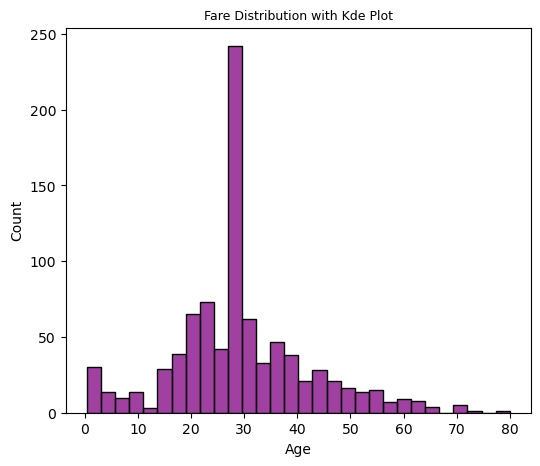

In [101]:
plt.figure(figsize=(6,5))
sns.histplot( data = df, x = 'Age', color='purple')
plt.title('Fare Distribution with Kde Plot', fontsize = 9)


- Age vs Fare scatter plot banao

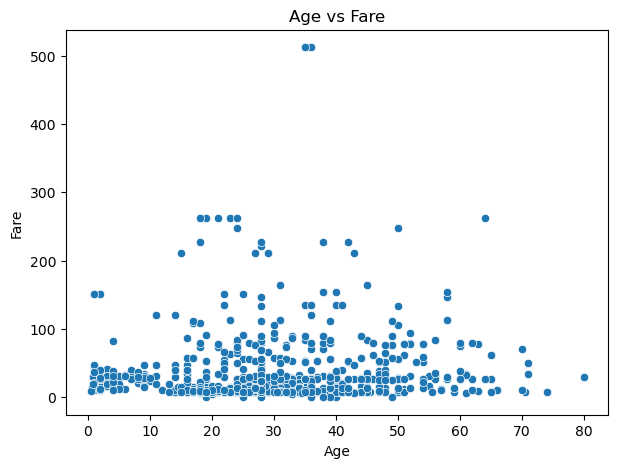

In [105]:
plt.figure(figsize=(7,5))
sns.scatterplot(data = df, x ='Age', y = 'Fare', palette='cividis')
plt.title('Age vs Fare')
plt.show()

- Correlation heatmap banao. 

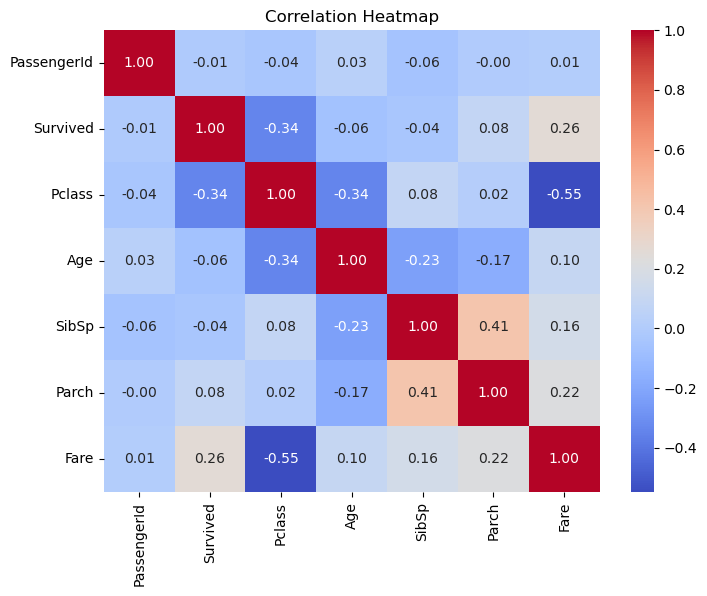

In [106]:
plt.figure(figsize=(8,6))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

- Pairplot banao numerical columns ka. 

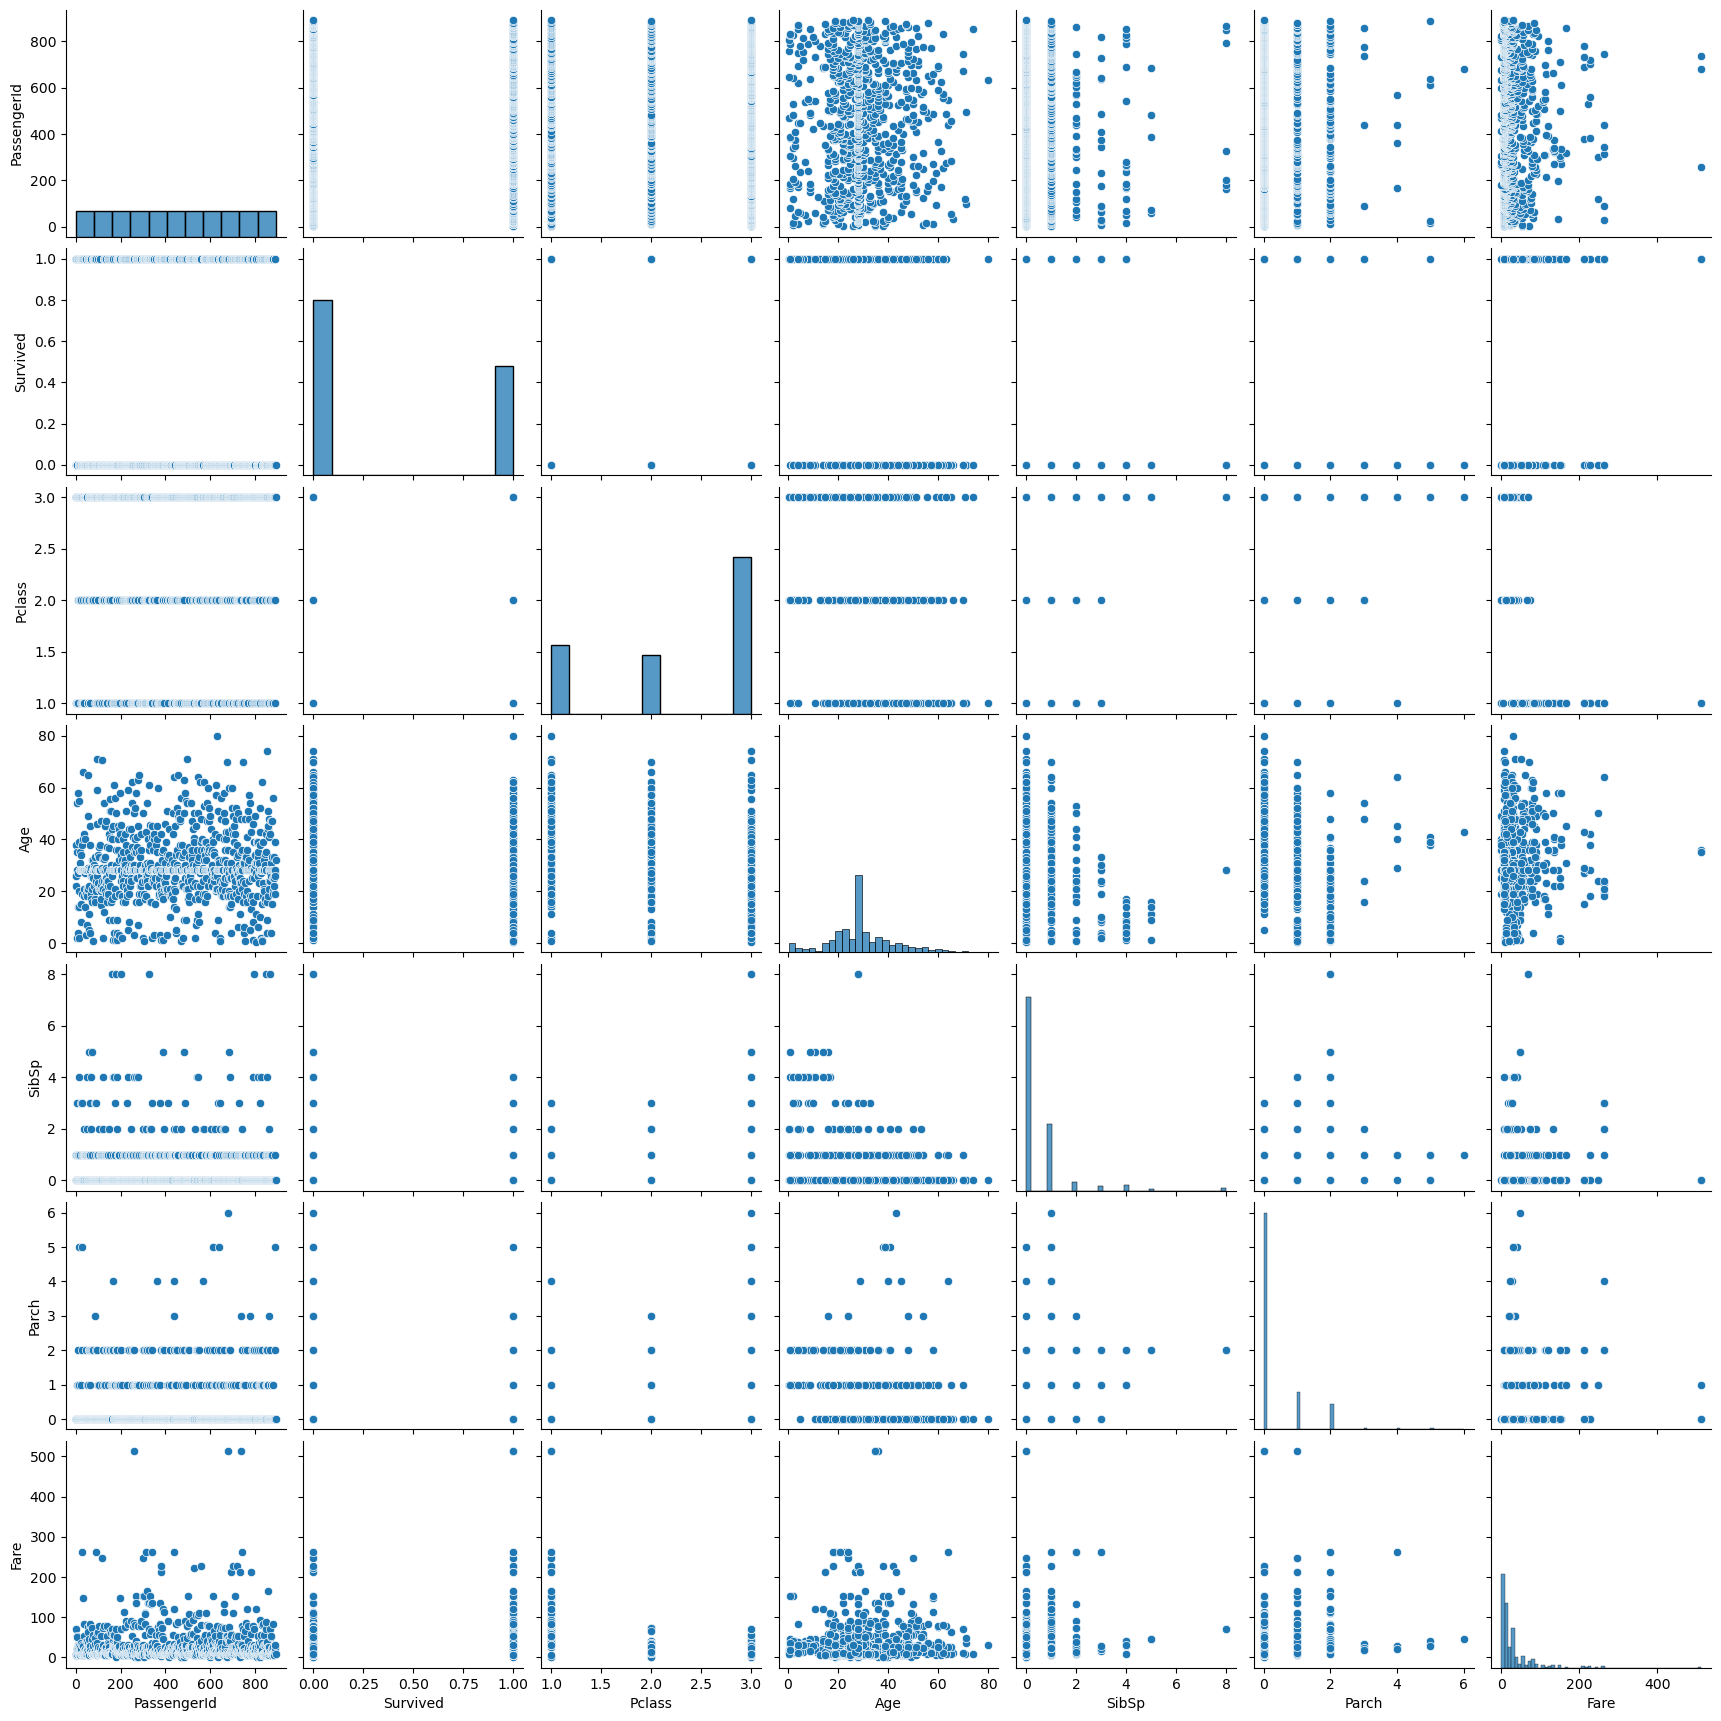

In [107]:
sns.pairplot(
    df.select_dtypes(include='number')
)

plt.show()

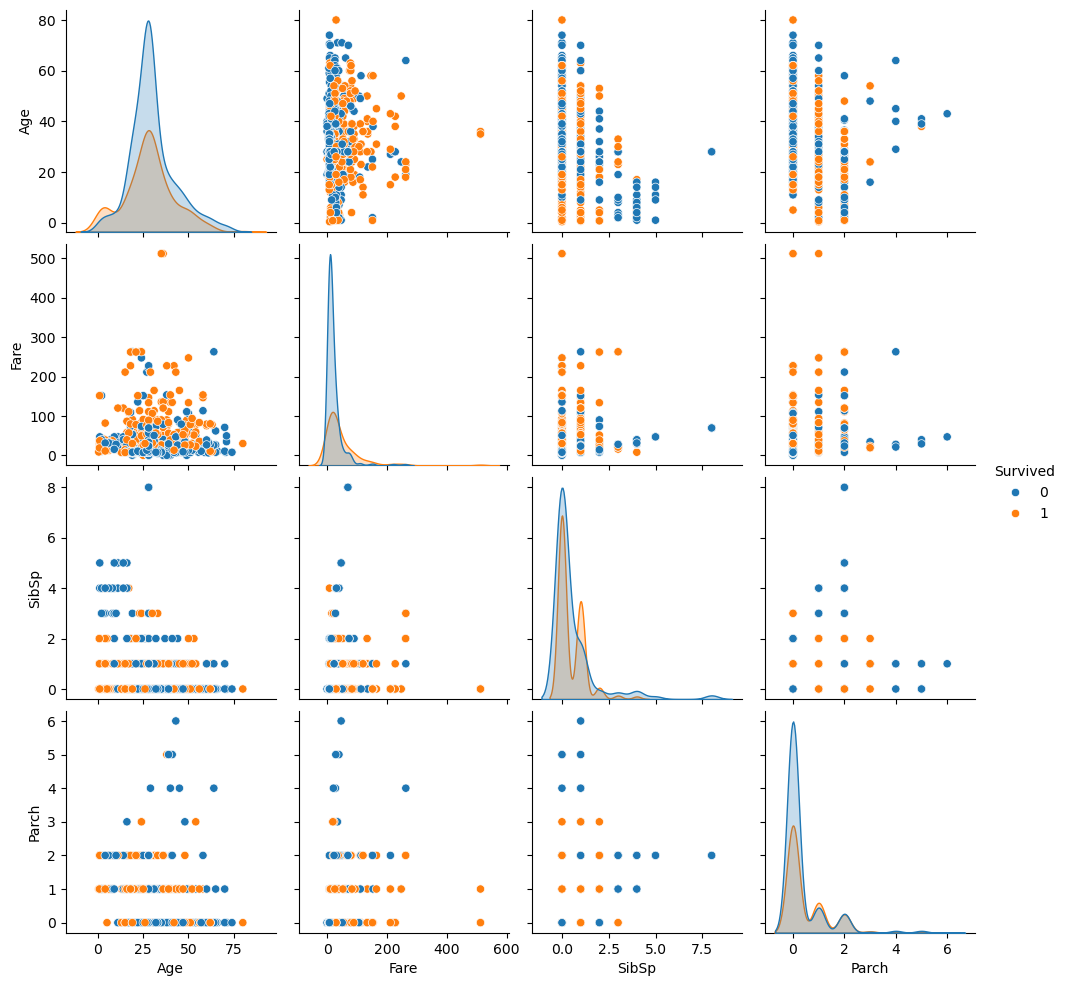

In [108]:
sns.pairplot(
    df,
    vars=['Age', 'Fare', 'SibSp', 'Parch'],
    hue='Survived'
)

plt.show()

# Titanic Dataset Summary Report

• Total Passengers: 891
• Total Survivors: 342
• Total Non-Survivors: 549
• Overall Survival Rate: 38.38%

• Female Survival Rate: 74.20%
• Male Survival Rate: 18.89%

• First Class Survival Rate: 62.96%
• Second Class Survival Rate: 47.28%
• Third Class Survival Rate: 24.24%

• Average Age: 29.70 years
• Average Fare: 32.20

• Most Common Passenger Class: Third Class
• Most Common Embarkation Port: Southampton (S)

• Highest Fare: 512.33
• Lowest Fare: 0.00

• Oldest Passenger: 80 years
• Youngest Passenger: 0.42 years

• Survival Rate who pay high Fare : 51.80 %
• Survival Rate who pay low fare : 25 %